## tl;dr

- 当前 Rank5 的问题是尾部亏损，不是低胜率：22 笔已平仓中 12 笔盈利，但净亏损 1,520.27 元，profit factor 只有 0.284。
- 历史完整账户回放中，Rank5 最多 1 手把净亏损收窄到 914.50 元，总收益提高 1.172 个百分点，且不增加订单或信号跳过率。
- 停用 Rank5 的历史总收益最高，但订单跳过率提高 2.386 个百分点；退出规则的增益较小，第 10 个交易日规则还截断了一笔最终盈利交易。
- 本轮没有候选通过现有晋级门禁。活跃 R14 不变，只冻结“Rank5 最多 1 手”为唯一前向候选。

## Context & Methods

目标是判断 Rank5 应该停用、降权还是增加结构性退出保护。所有变体使用同一份保留执行快照和同一完整账户回放，只改变 Rank5 风险控制。

### Key Assumptions

- 一手等于 100 股；候选选择仍按当前 R14 的完整目标仓位判断可买性，成交后才限制为最多一手。
- “晚期亏损保护”原样复用系统已有的收益不高于 -8%、距峰值回撤不高于 -10%、持有至少 10 个自然日条件，没有重新调阈值。
- “第 10 日仍低于买入价退出”只作为探索结果，不具备直接上线资格。
- 历史 22 笔 Rank5 样本很小，任何方向都必须经过独立前向样本。

## Data

来源：保留的确定性执行快照 `shortpick-v3-execution-snapshot-067c5b83e085f95f.json.gz`。分析脚本为 `scripts/research-shortpick-v3-rank5-risk-controls.py`。

In [1]:
from pathlib import Path
import runpy
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
SNAPSHOT_PATH = Path(
    "/Users/hernando_zhao/codex/runtime/projects/ashare-dashboard/data/artifacts/"
    "research_validation/rolling_account_execution_snapshots/"
    "shortpick-v3-execution-snapshot-067c5b83e085f95f.json.gz"
)
SCRIPT_PATH = PROJECT_ROOT / "scripts/research-shortpick-v3-rank5-risk-controls.py"
experiment_module = runpy.run_path(str(SCRIPT_PATH))
experiment = experiment_module["run_experiment"](SNAPSHOT_PATH)
assert experiment["status"] == "completed"
assert experiment["source_execution_snapshot"]["exact_replay"] is True
experiment["source_execution_snapshot"]

{'artifact_id': 'shortpick-v3-execution-snapshot-067c5b83e085f95f',
 'path': '/Users/hernando_zhao/codex/runtime/projects/ashare-dashboard/data/artifacts/research_validation/rolling_account_execution_snapshots/shortpick-v3-execution-snapshot-067c5b83e085f95f.json.gz',
 'expected_output_content_digest': '2f69c113db22357cbb3967ef7fc0490f828f06d4d6379045954d829d5e56403c',
 'observed_output_content_digest': '2f69c113db22357cbb3967ef7fc0490f828f06d4d6379045954d829d5e56403c',
 'exact_replay': True,
 'input_counts': {'candidate_inventory_row_count': 10220,
  'market_bar_row_count': 1420262,
  'market_bar_symbol_count': 1837,
  'selected_pick_count': 1533},
 'output_counts': {'nav_row_count': 675, 'order_ledger_row_count': 2326}}

## Results

下面把账户收益、跳过率和 Rank5 自身损益放在同一张审计表中。总收益和跳过率的差值均以百分点计。

In [2]:
baseline = experiment["results"][0]
rows = []
for result in experiment["results"]:
    summary = result["summary"]
    rank5 = result["rank5_diagnostics"]
    comparison = result["vs_current_r14"]
    rows.append({
        "方案": result["label"],
        "账户总收益": summary["total_return"],
        "总收益差_pp": comparison["deltas"]["total_return"] * 100,
        "最大回撤": summary["max_drawdown"],
        "订单跳过率": summary["skipped_order_rate"],
        "订单跳过率差_pp": comparison["deltas"]["skipped_order_rate"] * 100,
        "亏损月份": summary["negative_month_count"],
        "Rank5已平仓": rank5["closed_count"],
        "Rank5胜率": rank5["win_rate"],
        "Rank5净损益_元": rank5["net_pnl_cny"],
        "Rank5_profit_factor": rank5["profit_factor"],
        "通过晋级门禁": comparison["passed"],
    })
result_frame = pd.DataFrame(rows)
result_frame.style.format({
    "账户总收益": "{:.2%}",
    "总收益差_pp": "{:+.3f}",
    "最大回撤": "{:.2%}",
    "订单跳过率": "{:.2%}",
    "订单跳过率差_pp": "{:+.3f}",
    "Rank5胜率": "{:.1%}",
    "Rank5净损益_元": "{:,.2f}",
    "Rank5_profit_factor": "{:.3f}",
})

,方案,账户总收益,总收益差_pp,最大回撤,订单跳过率,订单跳过率差_pp,亏损月份,Rank5已平仓,Rank5胜率,Rank5净损益_元,Rank5_profit_factor,通过晋级门禁
0,当前 R14,332.10%,+0.000,-6.89%,15.15%,+0.000,2,22,54.5%,"-1,520.27",0.284,False
1,停用 Rank5,333.68%,+1.578,-6.88%,17.53%,+2.386,2,0,0.0%,0.00,0.000,False
2,Rank5 最多 1 手,333.27%,+1.172,-6.88%,15.15%,+0.000,2,22,54.5%,-914.50,0.241,False
3,Rank5 晚期亏损保护,332.22%,+0.124,-6.88%,15.15%,+0.000,2,22,54.5%,"-1,271.90",0.321,False
4,1 手 + 晚期亏损保护,333.57%,+1.470,-6.87%,15.25%,+0.104,2,22,54.5%,-714.01,0.289,False
5,第 10 日仍低于买入价退出,332.20%,+0.097,-6.88%,15.04%,-0.104,2,22,50.0%,"-1,437.48",0.225,False
6,1 手 + 第 10 日退出,333.45%,+1.348,-6.88%,15.15%,+0.000,2,22,50.0%,-676.10,0.227,False


### Rank5 风险控制后的净损益

所有保留 Rank5 的方案历史净损益仍为负。降仓的作用大于退出规则，但它只是减少风险暴露，尚未证明 Rank5 具有正期望。

/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_13242/3579757790.py:13: UserWarning: Glyph 24403 (\N{CJK UNIFIED IDEOGRAPH-5F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_13242/3579757790.py:13: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_13242/3579757790.py:13: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_13242/3579757790.py:13: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc7qc96ysgd4nvjtbgk__40000gn/T/ipykernel_13242/3579757790.py:13: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/b1/yntc

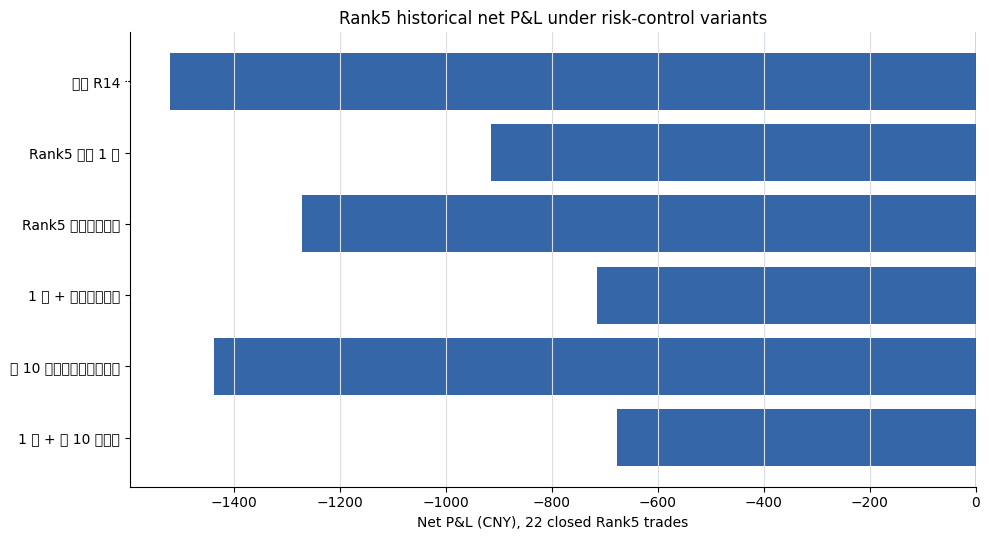

In [3]:
plot_frame = result_frame[result_frame["Rank5已平仓"] > 0].copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(plot_frame["方案"], plot_frame["Rank5净损益_元"], color="#3567A8")
ax.axvline(0, color="#28323C", linewidth=1)
ax.set_title("Rank5 historical net P&L under risk-control variants")
ax.set_xlabel("Net P&L (CNY), 22 closed Rank5 trades")
ax.invert_yaxis()
for bar, value in zip(bars, plot_frame["Rank5净损益_元"], strict=True):
    ax.text(value - 20, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}",
            va="center", ha="right", color="white", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#D9DEE5", linewidth=0.8)
plt.tight_layout()
plt.show()

### Reasonableness checks

- 当前 R14 精确复现保留快照。
- 一手上限仍保留 22 笔已平仓 Rank5 和 12 笔盈利，说明收益变化来自仓位而不是删样本。
- 停用 Rank5 的收益最高，但订单跳过率明显上升，因此不能按现有覆盖门禁晋级。
- 第 10 日规则使盈利笔数从 12 降到 11，验证了它会截断反弹型赢家。
- 所有候选的亏损月份仍为 2，均未达到现有突破条件。

In [4]:
by_id = {row["variant_id"]: row for row in experiment["results"]}
assert by_id["rank5_one_lot_cap"]["rank5_diagnostics"]["closed_count"] == 22
assert by_id["rank5_one_lot_cap"]["rank5_diagnostics"]["winner_count"] == 12
assert by_id["rank5_day10_below_entry"]["rank5_diagnostics"]["winner_count"] == 11
assert all(row["summary"]["negative_month_count"] == 2 for row in experiment["results"])
assert not any(row["vs_current_r14"]["passed"] for row in experiment["results"])
"All reasonableness checks passed."

'All reasonableness checks passed.'

## Takeaways

1. **不激活任何历史候选。** 没有方案减少亏损月份或达到 10% 级突破。
2. **唯一值得前向验证的是一手上限。** 它是最简单、覆盖损失最小的风险控制：Rank5 净亏损减少 605.77 元，订单与信号跳过率不变。
3. **不继续开发 Rank5 退出规则。** 通用晚期保护增益太小，第 10 日规则还会误杀反弹赢家。
4. **活跃策略保持不变。** 前向设计已冻结；只有满足既有 80 条成熟影子样本、20 笔实际已平仓 Rank5、12 个月及完整账户双基线门禁后，才允许一进一出替换 R14。